In [ ]:
import scipy.io
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pyod.models.pca import PCA
import matplotlib.pyplot as plt

mat = scipy.io.loadmat('shuttle.mat')
X = mat['X']
y = mat['y'].ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

contamination = np.mean(y_train == 1)

pca = PCA(contamination=contamination, random_state=1)
pca.fit(X_train_std)

PCA(contamination=np.float64(0.07152556181682396), copy=True,
  iterated_power='auto', n_components=None, n_selected_components=None,
  random_state=1, standardization=True, svd_solver='auto', tol=0.0,
  weighted=True, whiten=False)

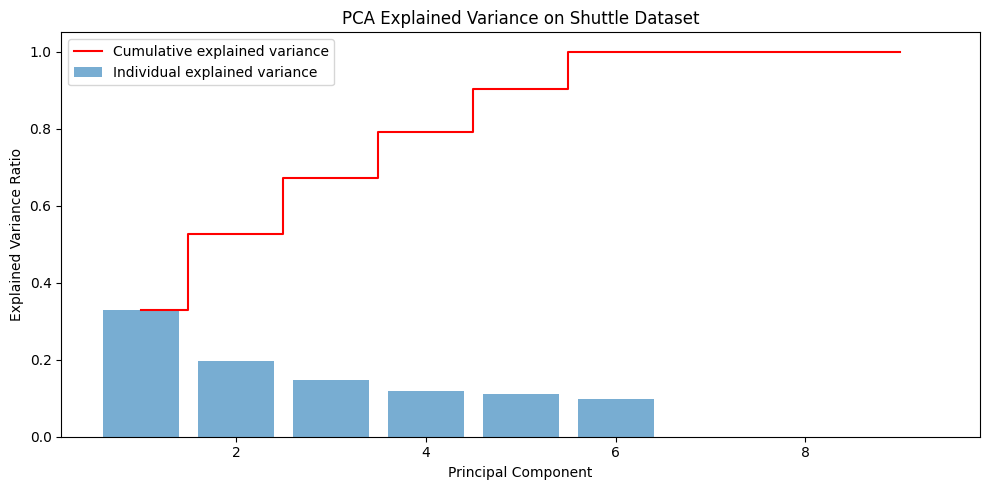

In [ ]:
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(10,5))
plt.bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, label='Individual explained variance')
plt.step(range(1, len(cumulative_var)+1), cumulative_var, where='mid', label='Cumulative explained variance', color='red')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance on Shuttle Dataset')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import balanced_accuracy_score

# labels (1=outlier, 0=inlier)
y_train_pred = pca.labels_
y_test_pred = pca.predict(X_test_std)

train_bal_acc = balanced_accuracy_score(y_train, y_train_pred)
test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)

print(f"PCA Balanced Accuracy - Train: {train_bal_acc:.3f}, Test: {test_bal_acc:.3f}")

PCA Balanced Accuracy - Train: 0.975, Test: 0.971


In [ ]:
from pyod.models.kpca import KPCA

kpca = KPCA(contamination=contamination, random_state=42)
kpca.fit(X_train_std)

y_train_pred_kpca = kpca.labels_
y_test_pred_kpca = kpca.predict(X_test_std)

train_bal_acc_kpca = balanced_accuracy_score(y_train, y_train_pred_kpca)
test_bal_acc_kpca = balanced_accuracy_score(y_test, y_test_pred_kpca)

print(f"KPCA Balanced Accuracy - Train: {train_bal_acc_kpca:.3f}, Test: {test_bal_acc_kpca:.3f}")